<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 2 · XGBoost & Random Forest</h4>
<h1 align="center">Random Forest — Hotel Booking Demand</h1>
<p align="center"><i>From a single decision tree to a forest: mechanics, tuning, and evaluation</i></p>

---


## Roadmap for this notebook

This is the deepest notebook of the four. We build up from first principles to a fully
evaluated, tuned model:

1. **CART mechanics** — how a single decision tree actually picks a split.
2. **Overfitting vs. underfitting** — the bias-variance tradeoff, demonstrated with a single
   tree at different depths.
3. **Random Forest mechanics** — bagging, random feature subsampling, out-of-bag error, and
   feature importance.
4. **Why Random Forest is such a big deal** — the case for why this family of models is still
   a default first choice on tabular data.
5. **Model hyperparameters** — a guided tour of every `RandomForestClassifier` knob that
   matters in practice, each demonstrated with a small sweep.
6. **Training and evaluating the final model** — accuracy, precision, recall, F1, ROC-AUC,
   confusion matrix, and feature importance, with guidance on reading each in a business
   context.
7. **The wider landscape** — Gini vs. entropy vs. misclassification error, and log loss.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    log_loss,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

train = pd.read_csv("data/hotel_processed_train.csv")
test = pd.read_csv("data/hotel_processed_test.csv")

X_train = train.drop(columns=["is_canceled"])
y_train = train["is_canceled"]
X_test = test.drop(columns=["is_canceled"])
y_test = test["is_canceled"]

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Train cancellation rate: {y_train.mean():.4%}   Test cancellation rate: {y_test.mean():.4%}")

Train: (69916, 81)   Test: (17480, 81)
Train cancellation rate: 27.4901%   Test cancellation rate: 27.4886%



## 1. CART mechanics — how a single decision tree picks a split

A decision tree (the CART algorithm — Classification And Regression Trees) grows by repeatedly
asking the single best yes/no question it can find about the data at each node:

> For every candidate **(feature, threshold)** pair, split the current node's rows into two
> children — those where `feature <= threshold` and those where `feature > threshold` — and
> measure how "pure" (homogeneous in class label) the two resulting children are. Keep
> whichever (feature, threshold) pair produces the **purest** children. Recurse on each child.
> Stop when a stopping rule is hit (e.g. a max depth, a minimum node size, or a node that is
> already pure).

"Purity" is measured with an **impurity function**. The two classic choices for
classification are **Gini impurity** and **entropy**.

### Gini impurity

For a node with $C$ classes and $p_i$ the proportion of samples in the node belonging to
class $i$:

$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

Gini is $0$ for a perfectly pure node (all one class) and reaches its maximum
($0.5$ for two classes) when the classes are perfectly balanced (a coin flip).

### Entropy

$$H = -\sum_{i=1}^{C} p_i \log_2 p_i$$

Entropy comes from information theory: it measures the average number of bits needed to
communicate which class a random sample from the node belongs to. Like Gini, it is $0$ for a
pure node and maximized ($1.0$ for two balanced classes) at a 50/50 split — but entropy
penalizes impurity slightly more aggressively near the extremes because of the logarithm.

### Choosing the best split: weighted impurity and information gain

For a candidate split that sends $n_L$ samples to the left child and $n_R$ to the right child
(out of $n = n_L + n_R$ samples at the parent), the **weighted child impurity** is:

$$Impurity_{children} = \frac{n_L}{n} \, Impurity(\text{left}) + \frac{n_R}{n} \, Impurity(\text{right})$$

and the **information gain** of the split is how much impurity we removed by making it:

$$Gain = Impurity(\text{parent}) - Impurity_{children}$$

The tree-building algorithm computes this gain for *every* candidate (feature, threshold)
pair available at a node, and picks the one with the largest gain. It then recurses on each
child, repeating the whole search from scratch on the smaller subset of data.


In [2]:
def gini(p):
    p = np.array(p, dtype=float)
    return 1 - np.sum(p ** 2)

def entropy(p):
    p = np.array(p, dtype=float)
    p = p[p > 0]  # 0 * log2(0) is defined as 0
    return -np.sum(p * np.log2(p))

# ---- A tiny, fully worked example -----------------------------------------
# 10 toy bookings. Feature: has_non_refund_deposit (1/0). Label: is_canceled (1/0).
toy = pd.DataFrame({
    "has_non_refund_deposit": [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    "is_canceled":            [1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
})
toy

,has_non_refund_deposit,is_canceled
0,1,1
1,1,1
2,1,1
3,1,1
4,1,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0



This toy parent node has 10 rows: **4 canceled, 6 not canceled**. The candidate split we are
evaluating is on `has_non_refund_deposit`: does requiring a non-refundable deposit separate
the cancellations well?


In [3]:
# Parent node proportions
p_parent = toy["is_canceled"].value_counts(normalize=True).sort_index().values  # [p(0), p(1)]
gini_parent = gini(p_parent)
h_parent = entropy(p_parent)
print(f"Parent proportions (p0, p1): {p_parent}")
print(f"Parent Gini:    {gini_parent:.4f}")
print(f"Parent entropy: {h_parent:.4f} bits")

Parent proportions (p0, p1): [0.6 0.4]
Parent Gini:    0.4800
Parent entropy: 0.9710 bits


In [4]:
left = toy[toy["has_non_refund_deposit"] == 1]   # 5 rows
right = toy[toy["has_non_refund_deposit"] == 0]  # 5 rows

p_left = left["is_canceled"].value_counts(normalize=True).reindex([0, 1], fill_value=0).values
p_right = right["is_canceled"].value_counts(normalize=True).reindex([0, 1], fill_value=0).values

gini_left, gini_right = gini(p_left), gini(p_right)
h_left, h_right = entropy(p_left), entropy(p_right)

n, n_left, n_right = len(toy), len(left), len(right)
w_left, w_right = n_left / n, n_right / n

gini_children = w_left * gini_left + w_right * gini_right
h_children = w_left * h_left + w_right * h_right

gini_gain = gini_parent - gini_children
entropy_gain = h_parent - h_children

print(f"Left child  (has_non_refund_deposit=1): 4 canceled / 5 rows -> p=(0.2, 0.8)")
print(f"  Gini:    {gini_left:.4f}   Entropy: {h_left:.4f} bits")
print(f"Right child (has_non_refund_deposit=0): 0 canceled / 5 rows -> pure")
print(f"  Gini:    {gini_right:.4f}   Entropy: {h_right:.4f} bits")
print()
print(f"Weighted child Gini:    {gini_children:.4f}   -> Gini information gain:    {gini_gain:.4f}")
print(f"Weighted child entropy: {h_children:.4f}   -> Entropy information gain: {entropy_gain:.4f} bits")

Left child  (has_non_refund_deposit=1): 4 canceled / 5 rows -> p=(0.2, 0.8)
  Gini:    0.3200   Entropy: 0.7219 bits
Right child (has_non_refund_deposit=0): 0 canceled / 5 rows -> pure
  Gini:    0.0000   Entropy: -0.0000 bits

Weighted child Gini:    0.1600   -> Gini information gain:    0.3200
Weighted child entropy: 0.3610   -> Entropy information gain: 0.6100 bits



Reading these numbers:

- The **right child is perfectly pure** (all 5 rows are "not canceled") — both Gini ($0$) and
  entropy ($0$ bits) agree completely on that.
- The **left child** is not pure (4 canceled, 1 not), so both measures assign it positive
  impurity — Gini $= 0.32$, entropy $\approx 0.72$ bits.
- Both criteria agree this is a **good split**: a large information gain either way (Gini gain
  $\approx 0.32$, entropy gain $\approx 0.61$ bits). This is the general pattern — **Gini and
  entropy usually agree on which candidate split is best**, because they are both concave
  functions of $p$ that are zero at the extremes and maximized at $p=0.5$. But notice the
  actual numeric values are **not identical** — entropy's logarithmic penalty makes it react
  slightly more sharply to impurity than Gini's quadratic penalty, so on more borderline
  candidate splits (unlike this clear-cut toy example) the two criteria can occasionally rank
  two close candidates in a different order. In `scikit-learn`, this is the
  `criterion="gini"` (default, and slightly cheaper to compute since it avoids logarithms) vs
  `criterion="entropy"` choice on `DecisionTreeClassifier` / `RandomForestClassifier`.

The real algorithm repeats exactly this calculation for *every* feature and *every* candidate
threshold at *every* node, all the way down the tree — which is also why deep trees on
wide datasets can get slow, and why Random Forest's random feature subsampling (Section 3)
is also a computational shortcut, not just a statistical one.



## 2. Overfitting vs. underfitting — the bias-variance tradeoff

A single decision tree has a knob that directly controls how complex it's allowed to become:
`max_depth`. This section makes the classic **bias-variance tradeoff** concrete:

- A **shallow** tree (small `max_depth`) can only ask a few questions before it has to commit
  to a prediction. It **underfits**: high bias, it hasn't captured enough structure in the
  data, and both train and test accuracy will be mediocre.
- A **fully grown** tree (`max_depth=None`) keeps splitting until every leaf is pure (or has
  too few samples to split further). It **memorizes the training set**, including its noise
  and quirks that don't generalize. This is **overfitting**: near-perfect train accuracy,
  but test accuracy that plateaus or even drops, because the tree has learned spurious
  patterns specific to the training rows rather than the underlying relationship.
- Somewhere in between is a **sweet spot** where the tree captures real structure without
  memorizing noise.

This single fact — that one fully-grown tree has *low bias but very high variance* — is the
entire motivation for ensembling many trees together, which is exactly what Random Forest
does in Section 3.


In [5]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
train_accs, test_accs = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))

depth_labels = [str(d) if d is not None else "None\n(full)" for d in depths]
depth_results = pd.DataFrame({"max_depth": depth_labels, "train_accuracy": train_accs, "test_accuracy": test_accs})
depth_results

,max_depth,train_accuracy,test_accuracy
0,1,0.725099,0.725114
1,2,0.757480,0.757323
2,3,0.778062,0.774371
3,4,0.793896,0.789989
4,5,0.801276,0.797654
5,6,0.814535,0.812929
6,8,0.827808,0.822712
7,10,0.837762,0.828490
8,15,0.881014,0.821339
9,20,0.940200,0.807437


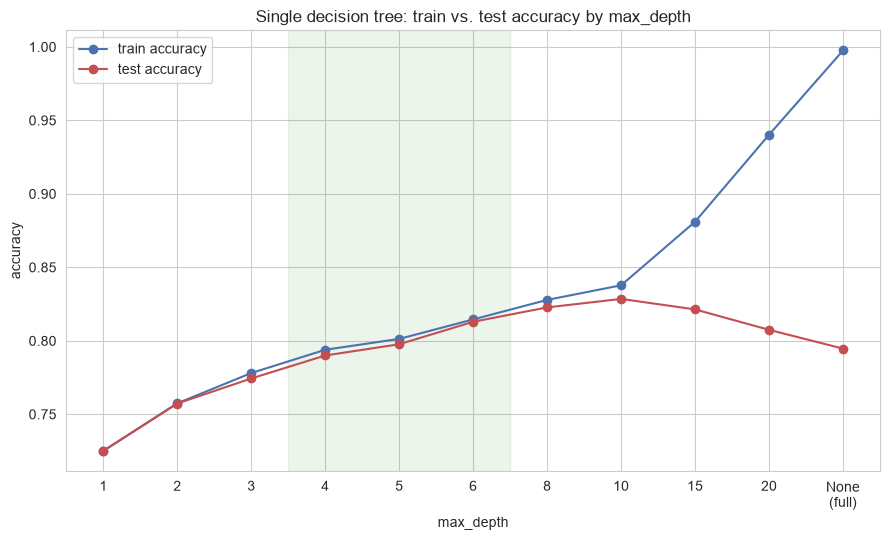

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x_pos = range(len(depths))
ax.plot(x_pos, train_accs, marker="o", label="train accuracy", color="#4C72B0")
ax.plot(x_pos, test_accs, marker="o", label="test accuracy", color="#C44E52")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(depth_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Single decision tree: train vs. test accuracy by max_depth")
ax.legend()
ax.axvspan(2.5, 5.5, color="green", alpha=0.08)
plt.tight_layout()
plt.show()


The classic pattern is visible:

- At very shallow depths (`max_depth` 1-2), **both** train and test accuracy are low — the
  tree is **underfitting**, too simple to capture the relationship.
- Train accuracy climbs steadily as depth increases and **keeps climbing all the way to
  ~100%** at `max_depth=None` — the tree is capable of perfectly memorizing the training set.
- Test accuracy climbs too, but only up to a point (the shaded "sweet spot" region), after
  which it **flattens out or degrades slightly** while train accuracy keeps rising. The
  growing *gap* between the two curves at large depths is the signature of **overfitting**:
  the tree is fitting noise specific to the training rows that does not generalize.

A single tree forces us to pick one `max_depth` and live with that tradeoff. Random Forest's
answer is different and, as we'll see, better: let individual trees **overfit** (grow deep,
low bias, high variance) and then **average away the variance** across many of them.



## 3. Random Forest mechanics

### Bootstrap aggregating (bagging)

Random Forest trains many decision trees, but each tree sees a different **bootstrap sample**
of the training data — a sample of size $n$ drawn *with replacement* from the original $n$
training rows (so, on average, each bootstrap sample contains about 63% of the unique
original rows, some duplicated, and leaves about 37% out entirely). Each tree is grown deep
and unpruned — exactly the high-variance, low-bias regime from Section 2 — and the forest's
prediction is the **average** (regression) or **majority vote** (classification) across all
trees.

### Why averaging correlated trees reduces variance without increasing bias

Averaging doesn't change the *bias* of an estimator: if each tree is (roughly) unbiased for
the true relationship, so is their average. What averaging changes is **variance**. For $B$
estimators, each with variance $\sigma^2$ and pairwise correlation $\rho$, the variance of
their average is:

$$\mathrm{Var}\left(\frac{1}{B}\sum_{b=1}^{B} T_b\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Two things fall out of this formula immediately:

- As $B \to \infty$, the second term vanishes, but the **first term, $\rho\sigma^2$, does
  not** — it's a floor on how much averaging alone can help. If the trees were perfectly
  correlated ($\rho = 1$), averaging a million of them would do nothing at all.
- This is *exactly* why bagging alone (bootstrap resampling only) has limited benefit: trees
  trained on highly overlapping bootstrap samples of the same data end up fairly similar to
  each other (correlated), because the strongest features dominate every tree's early splits
  regardless of which bootstrap sample it saw.

**Random feature subsampling at each split** — at every node, only considering a random
subset of `max_features` columns as split candidates, instead of all of them — is the
mechanism that specifically drives $\rho$ down further. If the single strongest feature isn't
even *available* as a candidate at a given split (because it wasn't in that node's random
feature subset), the tree is forced to use a different, weaker-but-still-useful feature
instead — which decorrelates it from trees that did have access to the dominant feature. Lower
$\rho$ directly shrinks the $\rho\sigma^2$ floor in the formula above, which is precisely why
Random Forest (bagging **+** feature subsampling) generalizes better than bagging alone.

### Out-of-bag (OOB) error: validation for free

Because each tree only trains on a bootstrap sample (~63% of rows), the remaining ~37% of rows
were **never seen by that tree**. Averaging each row's predictions across only the trees that
*didn't* see it during training gives an honest estimate of test performance — without
needing to hold out a separate validation set at all. `scikit-learn` computes this
automatically when `oob_score=True`.


In [7]:
rf_oob = RandomForestClassifier(
    n_estimators=200, max_features="sqrt", oob_score=True,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf_oob.fit(X_train, y_train)

oob_acc = rf_oob.oob_score_
test_acc = accuracy_score(y_test, rf_oob.predict(X_test))

print(f"OOB accuracy estimate (from training data alone): {oob_acc:.4%}")
print(f"Actual held-out test accuracy:                     {test_acc:.4%}")

OOB accuracy estimate (from training data alone): 85.1007%
Actual held-out test accuracy:                     85.2346%



The OOB estimate, computed entirely from the training set, tracks the real held-out test
accuracy closely — this is the "free" validation signal bagging gives us. It is genuinely
useful when data is scarce enough that setting aside a separate validation split feels
wasteful; here we have plenty of data, so we'll keep using the explicit test set as our
primary yardstick, but it's worth knowing OOB score exists for exactly that situation.

### Feature importance

Random Forest also gives us **feature importance** essentially for free: for each feature,
scikit-learn tracks the total impurity decrease (Section 1's information gain) it was
responsible for, averaged across every split, in every tree, weighted by how many samples
reached that split. Features that produce large, frequent impurity reductions score higher.


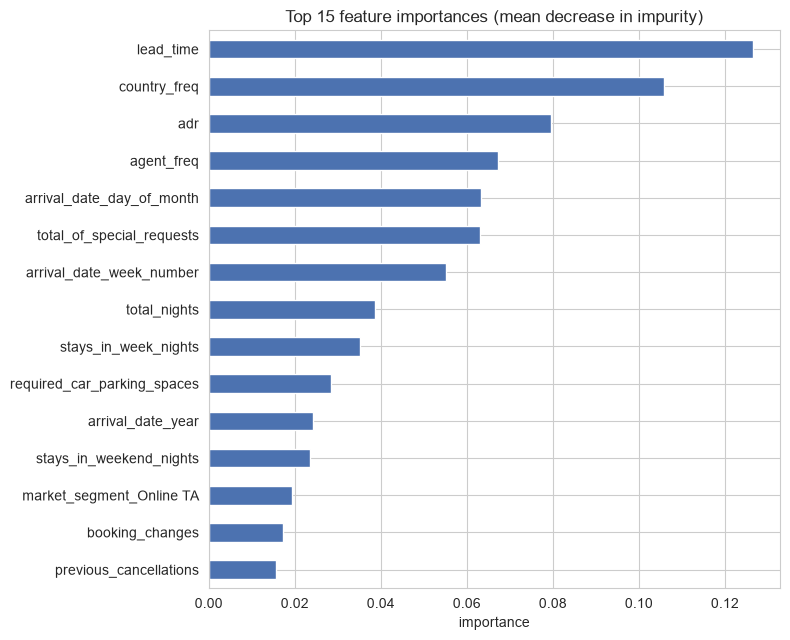

lead_time                      0.126476
country_freq                   0.105916
adr                            0.079615
agent_freq                     0.067297
arrival_date_day_of_month      0.063328
total_of_special_requests      0.062991
arrival_date_week_number       0.055079
total_nights                   0.038764
stays_in_week_nights           0.035267
required_car_parking_spaces    0.028492
arrival_date_year              0.024132
stays_in_weekend_nights        0.023483
market_segment_Online TA       0.019443
booking_changes                0.017183
previous_cancellations         0.015526
dtype: float64

In [8]:
importances = pd.Series(rf_oob.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_n = 15

fig, ax = plt.subplots(figsize=(8, 6.5))
importances.head(top_n).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title(f"Top {top_n} feature importances (mean decrease in impurity)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

importances.head(top_n)


Consistent with the EDA notebook, `lead_time`, the deposit-type flags, and the frequency-
encoded `agent`/`country` columns dominate the importance ranking — the forest is
"discovering," purely from impurity reduction, the same signals we spotted visually earlier.
This is a good sanity check: when a model's own feature importances line up with what EDA
already suggested, that's a sign the model is picking up real structure rather than noise.



## 4. Why Random Forest is such a big deal

It's worth being explicit about why this specific algorithm, invented in the early 2000s, is
still one of the first things a practitioner reaches for on a new tabular dataset, decades
later and in the era of deep learning and gradient boosting:

- **Minimal preprocessing.** No feature scaling, no need to hand-engineer interactions —
  trees split on raw thresholds and naturally capture non-linearities and interactions that a
  linear model would need explicit feature engineering to see. It handles a mix of numeric
  and encoded categorical columns (exactly what we built in `02_data_processing.ipynb`)
  without complaint.
- **Hard to badly overfit.** Section 2 showed a single tree overfits badly at full depth. But
  a *forest* of such trees, averaged together, is inherently variance-reducing — even with
  hundreds of deep, individually-overfit trees, the ensemble as a whole tends to generalize
  far better than any one of its members, and typically keeps improving (or at least not
  getting worse) as you add more trees, rather than requiring the kind of careful early
  stopping that boosting or neural networks need.
- **Trivial to parallelize.** Every tree is trained independently on its own bootstrap
  sample — there's no sequential dependency between them, so training scales almost linearly
  with the number of CPU cores available (`n_jobs=-1`).
- **Feature importance for free.** No separate interpretability tooling is required to get a
  first-pass ranking of what mattered.
- **Robust to outliers and missing-pattern quirks.** Because splits are threshold-based rather
  than distance- or gradient-based, a handful of extreme outlier values in one feature has far
  less influence on a tree split than it would on, say, a linear regression coefficient.
- **A genuinely strong "just works" baseline** across a wide range of real industries — fraud
  detection, credit risk scoring, customer churn prediction, medical risk stratification, and
  demand forecasting problems that look exactly like this one (predicting whether a hotel
  booking will be canceled). In every one of these domains, the underlying data is
  fundamentally tabular and structured — rows of transactions, claims, patients, or bookings
  with a mix of numeric and categorical fields — which is precisely the setting Random Forest
  was built for.

> **The bigger picture:** an enormous share of real-world enterprise data is still tabular,
> not images or free text. As long as that remains true, tree ensembles like Random Forest
> are not a legacy technique to be replaced by something fancier — they are a default first
> baseline you fit *before* reaching for anything more complex, and one that is often hard to
> meaningfully beat without a lot of additional effort (which is exactly the case gradient
> boosting methods like XGBoost, covered in the next topic, have to make for themselves).



## 5. Model hyperparameters

`RandomForestClassifier` has a handful of hyperparameters that matter in practice. We walk
through each below and demonstrate its effect with a small sweep on this dataset, rather than
just describing it in the abstract.

### `n_estimators` — how many trees

More trees means the ensemble average in Section 3's variance formula,
$\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$, gets closer to its floor of $\rho\sigma^2$ — but the
*benefit per additional tree shrinks quickly* once $B$ is reasonably large, while training and
prediction cost keep growing roughly linearly. In practice this means there's a point past
which adding more trees costs compute for essentially no accuracy gain.


In [9]:
n_estimators_grid = [50, 150, 300]
rows = []

for n in n_estimators_grid:
    rf = RandomForestClassifier(n_estimators=n, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    rows.append({
        "n_estimators": n,
        "test_accuracy": accuracy_score(y_test, preds),
        "test_f1": f1_score(y_test, preds),
    })

n_estimators_results = pd.DataFrame(rows)
n_estimators_results

,n_estimators,test_accuracy,test_f1
0,50,0.846854,0.697685
1,150,0.851259,0.707537
2,300,0.851087,0.707298


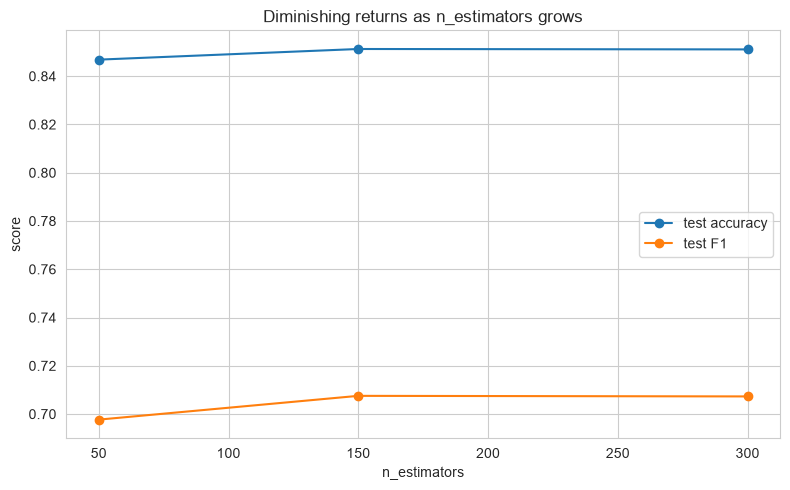

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_estimators_results["n_estimators"], n_estimators_results["test_accuracy"], marker="o", label="test accuracy")
ax.plot(n_estimators_results["n_estimators"], n_estimators_results["test_f1"], marker="o", label="test F1")
ax.set_xlabel("n_estimators")
ax.set_ylabel("score")
ax.set_title("Diminishing returns as n_estimators grows")
ax.legend()
plt.tight_layout()
plt.show()


Notice how little the score moves between 150 and 300 trees compared to the jump from 50 to
150 — classic diminishing returns. A sensible practical default is "enough trees that the
score has clearly flattened," which for this dataset is comfortably within the 150-300 range
called for by this workshop's compute budget.

### `max_depth` — ties directly into Section 2

`max_depth` controls each individual tree's complexity exactly as it did for the single tree
in Section 2 — a shallow forest underfits, an unconstrained forest lets each tree overfit
individually. The key difference is that Random Forest is *far more forgiving* of a large or
unlimited `max_depth` than a single tree was, precisely because of the averaging effect from
Section 3: even if every tree in the forest is individually overfit to its own bootstrap
sample, the ensemble average is not nearly as overfit as any single member. This is why the
common default for Random Forest is simply `max_depth=None` (grow trees fully), whereas for a
*single* decision tree we would tune `max_depth` carefully — the finding from Section 2's
"sweet spot" curve is a single-tree phenomenon that the forest structurally sidesteps.

### `min_samples_split` and `min_samples_leaf` — smoothing individual trees

- `min_samples_split`: a node must have at least this many samples before it's allowed to
  split further.
- `min_samples_leaf`: a split is only accepted if *both* resulting children end up with at
  least this many samples.

Both act as a brake on individual-tree complexity, similar in spirit to `max_depth`, but more
targeted: they specifically prevent a tree from creating tiny, high-variance leaves that
capture a handful of idiosyncratic training rows. Larger values -> smoother, less overfit
individual trees (higher bias, lower variance per tree); the default of `1` for
`min_samples_leaf` lets trees split all the way down to single-sample leaves.


In [11]:
leaf_grid = [1, 5, 20, 50]
rows = []

for leaf in leaf_grid:
    rf = RandomForestClassifier(
        n_estimators=200, max_features="sqrt", min_samples_leaf=leaf,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    rows.append({
        "min_samples_leaf": leaf,
        "train_accuracy": accuracy_score(y_train, rf.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, preds),
        "test_f1": f1_score(y_test, preds),
    })

leaf_results = pd.DataFrame(rows)
leaf_results

,min_samples_leaf,train_accuracy,test_accuracy,test_f1
0,1,0.997526,0.852346,0.709576
1,5,0.891541,0.845366,0.685002
2,20,0.848761,0.835240,0.650401
3,50,0.833171,0.825744,0.617241



As `min_samples_leaf` grows, train accuracy drops (each tree is less free to memorize
individual rows) while test accuracy stays roughly flat or dips only slightly at large
values — the gap between train and test accuracy narrows, which is the smoothing effect we'd
expect. Push it too far, though, and even the forest starts to underfit, since every tree is
now too constrained to capture real structure.

### `max_features` — the decorrelation knob

This is the parameter that most directly controls $\rho$, the tree-to-tree correlation in
Section 3's variance formula. It sets how many features are randomly considered as candidates
at *each individual split* (not once per tree — freshly re-sampled at every node).

- `max_features="sqrt"` (the classification default): only $\sqrt{p}$ features considered per
  split, out of $p$ total — aggressive decorrelation.
- `max_features=None` (all features): every split considers every feature, which is closer to
  plain bagging (no feature subsampling) — trees stay more correlated with each other because
  the strongest features tend to dominate every tree's top splits.


In [12]:
max_features_grid = ["sqrt", "log2", None]
rows = []

for mf in max_features_grid:
    rf = RandomForestClassifier(
        n_estimators=200, max_features=mf, oob_score=True,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    rows.append({
        "max_features": "all" if mf is None else mf,
        "oob_accuracy": rf.oob_score_,
        "test_accuracy": accuracy_score(y_test, preds),
        "test_f1": f1_score(y_test, preds),
    })

max_features_results = pd.DataFrame(rows)
max_features_results

,max_features,oob_accuracy,test_accuracy,test_f1
0,sqrt,0.851007,0.852346,0.709576
1,log2,0.847832,0.846796,0.694013
2,all,0.848947,0.847197,0.710272



On this dataset the effect is modest but present — restricting `max_features` typically holds
up at least as well as using all features, while being **much cheaper to compute** per split
(examining fewer candidate features at each node) and, per the bias-variance argument in
Section 3, more robust to a single dominant feature over-correlating the trees. This is why
`"sqrt"` is `scikit-learn`'s classification default rather than `None`.

### `class_weight` — handling the natural class imbalance

Recall the natural cancellation rate here is about 27% canceled / 73% not canceled — a real,
if moderate, class imbalance. By default, Random Forest (like most classifiers) optimizes for
overall accuracy, which can under-weight the minority class (cancellations) since getting
those wrong costs less to the loss the model is implicitly minimizing than the sheer volume of
majority-class rows would suggest. `class_weight="balanced"` re-weights each class inversely
proportional to its frequency, effectively telling the trees "getting a cancellation wrong
costs as much as getting a non-cancellation wrong," which tends to trade some overall accuracy
for better recall on the minority class.


In [13]:
rows = []
for cw in [None, "balanced"]:
    rf = RandomForestClassifier(
        n_estimators=200, max_features="sqrt", class_weight=cw,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    rows.append({
        "class_weight": "None" if cw is None else cw,
        "test_accuracy": accuracy_score(y_test, preds),
        "test_precision": precision_score(y_test, preds),
        "test_recall": recall_score(y_test, preds),
        "test_f1": f1_score(y_test, preds),
    })

class_weight_results = pd.DataFrame(rows)
class_weight_results

,class_weight,test_accuracy,test_precision,test_recall,test_f1
0,None,0.852346,0.772415,0.656191,0.709576
1,balanced,0.846224,0.701121,0.767950,0.733015



With `class_weight="balanced"`, **recall on cancellations typically rises** (the model catches
more true cancellations) at some cost to precision and overall accuracy (it also flags more
non-cancellations as cancellations). Which tradeoff is "better" is a business decision, not a
purely statistical one — see Section 6 for exactly this discussion in the context of
overbooking strategy.

### `n_jobs` and `random_state` — practical housekeeping

- `n_jobs=-1` tells scikit-learn to train trees across all available CPU cores in parallel —
  since each tree is independent (Section 3), this is a "free" speedup with no accuracy
  tradeoff at all. We've been using it throughout this notebook.
- `random_state` fixes the randomness used for bootstrap sampling and feature subsampling, so
  results are reproducible run to run. It has no effect on the model's *expected* quality,
  only on which specific random draws you happen to get on any one run.

### Putting it together

The comparison tables above make the point of this whole section concrete: instead of
describing what a hyperparameter "should" do, sweep it and look at the actual accuracy/F1/
ROC-AUC movement. The final model trained in Section 6 uses reasonable defaults informed by
these sweeps: a moderate `n_estimators` (within this workshop's compute budget),
`max_features="sqrt"` for decorrelation, and unrestricted `max_depth` (since, per Section 4,
the forest structure itself controls overfitting far better than a single tree's depth limit
would).



## 6. Training and evaluating the final model

We now fit the model we'll actually use for evaluation, using the settings justified above.


In [14]:
final_rf = RandomForestClassifier(
    n_estimators=250,
    max_features="sqrt",
    max_depth=None,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_rf.fit(X_train, y_train)

y_pred = final_rf.predict(X_test)
y_proba = final_rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8517
Precision: 0.7695
Recall:    0.6574
F1 score:  0.7091
ROC-AUC:   0.9129



**How to read each metric here:**

- **Accuracy** — overall share of correct predictions. With a moderate ~27/73 class split
  this is not badly misleading (unlike the extreme-imbalance settings discussed in the
  logistic regression topic), but it still blends together two very different kinds of
  mistakes, which is why we look at precision/recall separately.
- **Precision** — of the bookings the model *flagged* as likely cancellations, what fraction
  actually canceled. Low precision means a lot of false alarms — wasted effort on bookings
  that were actually going to show up.
- **Recall** — of the bookings that *actually* canceled, what fraction the model caught. This
  is the critical number for a hotel's **overbooking strategy**: a false negative here means
  a booking the model predicted would show up, that in fact canceled — a missed opportunity
  to resell that room, and potentially unnecessary conservatism in overbooking targets that
  costs the hotel occupancy revenue. A false positive (predicted cancel, actually shows up),
  by contrast, risks an oversold room and an angry guest at check-in. Neither error is free,
  which is exactly why the `class_weight` tradeoff in Section 5 is a genuine business decision.
- **F1 score** — the harmonic mean of precision and recall, a single number that penalizes
  models which sacrifice one for the other too aggressively.
- **ROC-AUC** — how well the model's predicted *probabilities* rank cancellations above
  non-cancellations across every possible decision threshold, not just the default 0.5 cutoff.
  A score of 0.5 is random guessing; 1.0 is perfect ranking. This is the metric to watch if
  the hotel later wants to pick a custom threshold (e.g. flag anything above a 30% predicted
  cancellation probability) rather than living with scikit-learn's default 50% cutoff.


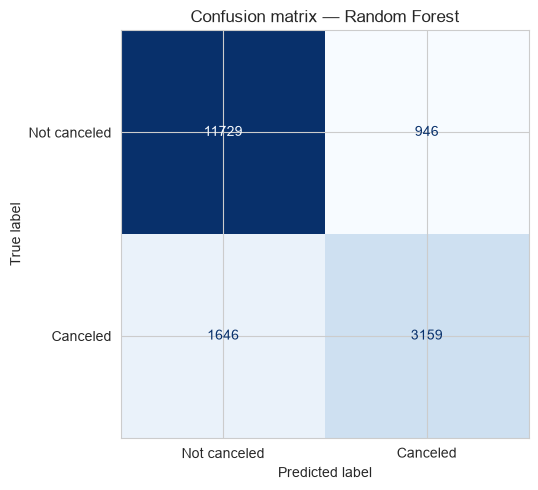

True negatives:  11,729  (correctly predicted: will show up)
False positives: 946  (predicted cancel, actually showed up -> risk of an unnecessarily oversold room)
False negatives: 1,646  (predicted show up, actually canceled -> missed resale opportunity)
True positives:  3,159  (correctly predicted: will cancel)


In [15]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Not canceled", "Canceled"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix — Random Forest")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives:  {tn:,}  (correctly predicted: will show up)")
print(f"False positives: {fp:,}  (predicted cancel, actually showed up -> risk of an unnecessarily oversold room)")
print(f"False negatives: {fn:,}  (predicted show up, actually canceled -> missed resale opportunity)")
print(f"True positives:  {tp:,}  (correctly predicted: will cancel)")

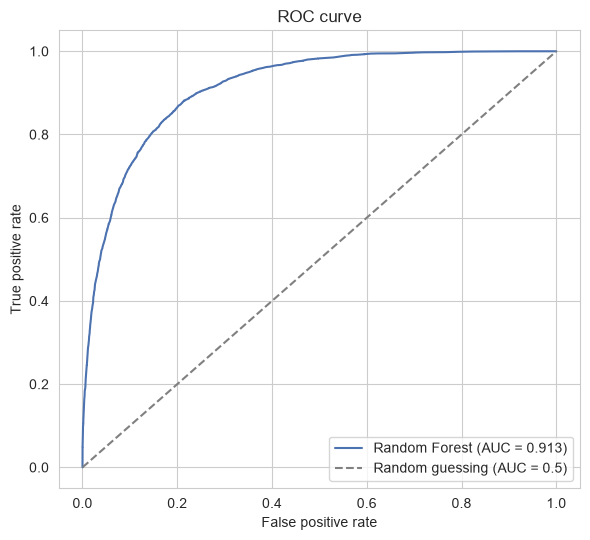

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(fpr, tpr, color="#4C72B0", label=f"Random Forest (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing (AUC = 0.5)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve")
ax.legend()
plt.tight_layout()
plt.show()

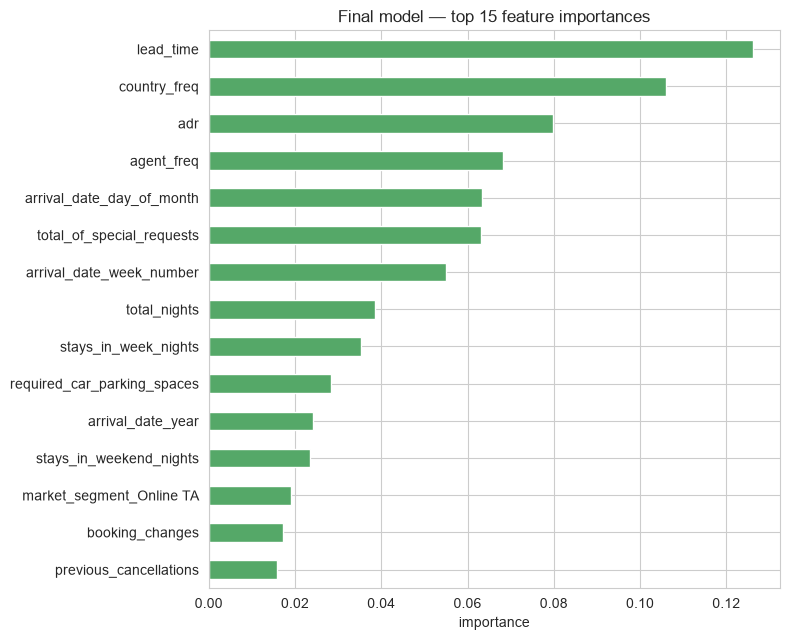

lead_time                      0.126140
country_freq                   0.105958
adr                            0.079752
agent_freq                     0.068157
arrival_date_day_of_month      0.063276
total_of_special_requests      0.063011
arrival_date_week_number       0.055114
total_nights                   0.038544
stays_in_week_nights           0.035249
required_car_parking_spaces    0.028383
arrival_date_year              0.024169
stays_in_weekend_nights        0.023375
market_segment_Online TA       0.019065
booking_changes                0.017142
previous_cancellations         0.015771
dtype: float64

In [17]:
final_importances = pd.Series(final_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6.5))
final_importances.head(15).sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Final model — top 15 feature importances")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

final_importances.head(15)


The final model's feature importances confirm what both the EDA notebook and the earlier OOB
model already suggested: lead time, deposit type, and how "common" the booking's country and
agent are (via our frequency encoding) dominate the ranking. This consistency across three
independent checks — visual EDA, an OOB-scored forest, and the tuned final forest — is a good
sign that the model has converged on genuine signal rather than an artifact of one particular
random seed or configuration.



## 7. The wider landscape: impurity measures and probability-based metrics

### Three classic impurity measures

We've used Gini and entropy throughout, but there is a third classic option worth knowing:
**misclassification error** (also called the "resubstitution" or "classification" error at a
node):

$$Error = 1 - \max_i p_i$$

This simply asks "if I had to make one prediction for this whole node, using majority vote,
how often would I be wrong?" It is the simplest of the three, but it is **not differentiable**
at the boundary and, more importantly for tree-building, it is **less sensitive to changes in
class probabilities away from the boundary** — two candidate splits can have identical
misclassification error while one produces genuinely purer children by the Gini or entropy
measures. This makes it a poor choice for *growing* a tree (it doesn't discriminate between
candidate splits as finely), even though it's exactly the quantity you often care about when
*evaluating* a finished tree's leaf predictions.

**When each is preferred:**

- **Gini** — the default for `RandomForestClassifier`/`DecisionTreeClassifier` in
  scikit-learn; slightly cheaper to compute (no logarithms) and behaves almost identically to
  entropy in practice.
- **Entropy** — historically preferred in information-theoretic contexts (it's the basis of
  the original ID3/C4.5 tree algorithms) and penalizes uncertainty slightly more sharply near
  the extremes; in practice, differences from Gini are usually marginal.
- **Misclassification error** — rarely used to *grow* trees for the reason above, but is
  exactly the number you're computing whenever you report a tree's or forest's plain accuracy.

### Log loss: judging probabilities, not just hard labels

Accuracy, precision, recall, and F1 all operate on the model's **hard** 0/1 predictions
(after applying some threshold, by default 0.5, to `predict_proba`). But
`RandomForestClassifier.predict_proba` gives us a continuous cancellation probability for
every booking — and if we only ever look at the hard label, we throw away information about
*how confident* the model was. **Log loss** (binary cross-entropy) is the standard metric for
judging predicted probabilities directly:

$$LogLoss = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\Big]$$

where $y_i \in \{0, 1\}$ is the true label and $\hat{p}_i$ is the model's predicted
probability of cancellation for booking $i$. Log loss **punishes confident wrong answers much
more severely than accuracy does** — predicting a 99% cancellation probability for a booking
that in fact showed up costs far more log loss than predicting 55%, even though both would be
scored as simply "wrong" if we only looked at the hard 0.5-threshold prediction. This is the
metric to reach for whenever you care about the *calibration* of the model's confidence, not
just whether its majority-vote prediction happened to be right.


In [18]:
ll = log_loss(y_test, y_proba)
print(f"Log loss (final Random Forest): {ll:.4f}")

# For comparison: what would log loss be for a "confidently wrong" naive model
# that always predicts the training-set base rate as its probability for every row?
naive_proba = np.full_like(y_proba, y_train.mean())
naive_ll = log_loss(y_test, naive_proba)
print(f"Log loss (naive: always predict base rate {y_train.mean():.4f}): {naive_ll:.4f}")

Log loss (final Random Forest): 0.3343
Log loss (naive: always predict base rate 0.2749): 0.5881



The trained forest's log loss is substantially lower than the naive baseline's — confirming
that its predicted probabilities are meaningfully better calibrated than simply always
guessing the overall base rate, on top of everything the hard-label metrics in Section 6
already told us.



## Summary

- Worked through exactly how a decision tree evaluates candidate splits using Gini and
  entropy, by hand, on a small concrete example.
- Demonstrated the bias-variance tradeoff directly: a single tree underfits when shallow and
  overfits when fully grown, motivating ensembling.
- Explained and demonstrated Random Forest's two key mechanisms — bagging and random feature
  subsampling — and connected them explicitly to the variance formula
  $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$, plus out-of-bag error and feature importance.
- Made the case for why Random Forest remains a top default choice on tabular data across
  many real industries.
- Swept every hyperparameter that matters in practice (`n_estimators`, `max_depth`,
  `min_samples_split`/`leaf`, `max_features`, `class_weight`, `n_jobs`, `random_state`) with
  concrete before/after comparisons rather than describing them abstractly.
- Trained and evaluated a final model, with metrics tied back to a concrete business
  consequence (overbooking strategy) for this specific dataset.
- Closed with the wider landscape of impurity measures (Gini, entropy, misclassification
  error) and log loss as the metric for judging predicted probabilities rather than hard
  labels.
